# Figure 2 generation notebook

This notebook regenerates manuscript Figure 2 from the `FIG2.zip` data archive in the same folder. No synthetic or placeholder data are generated.


Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIG2.svg


Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIG2.pdf


Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIG2.png


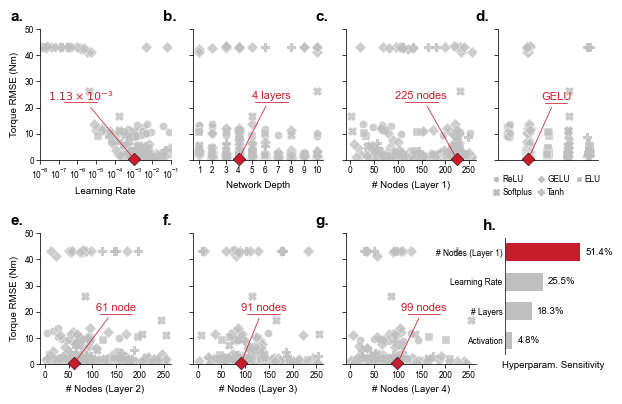

In [1]:
from pathlib import Path
import json
import zipfile
from io import TextIOWrapper

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import LogFormatterMathtext, LogLocator, NullFormatter

# -----------------------------------------------------------------------------
# Load data. FIG2.zip must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIG2.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIG2")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIG2.zip or FIG2 in the current folder. "
        "Place the data archive in the same folder as FIG2.ipynb."
    )

with zipfile.ZipFile(DATA_ARCHIVE) as archive:
    trials = pd.read_csv(archive.open("fig2_hyperparameter_trials.csv"))
    sensitivity = pd.read_csv(archive.open("fig2_hyperparameter_sensitivity.csv"))
    with archive.open("fig2_best_configuration.json") as handle:
        best_config = json.load(TextIOWrapper(handle, encoding="utf-8"))

# Keep all trials from the saved Optuna search, including pruned trials with
# recorded objective values, matching the original hyperparameter-search output.
trials = trials.copy()
trials = trials[np.isfinite(trials["torque_rmse_nm"])].copy()

# -----------------------------------------------------------------------------
# Figure style.
# -----------------------------------------------------------------------------
RED = "#C61C2C"
GREY = "#BFBFBF"
DARK_GREY = "#444444"
MARKERS = {
    "ReLU": "o",
    "GELU": "D",
    "ELU": "s",
    "Softplus": "X",
    "Tanh": "P",
}
ACTIVATION_ORDER = ["ReLU", "GELU", "ELU", "Softplus", "Tanh"]
ACTIVATION_TO_X = {name: idx for idx, name in enumerate(ACTIVATION_ORDER)}
PANEL_LABELS = list("abcdefgh")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.55,
    "xtick.major.width": 0.55,
    "ytick.major.width": 0.55,
    "xtick.minor.width": 0.45,
    "ytick.minor.width": 0.45,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


def style_scatter_axis(ax, show_ylabel=False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, 50)
    ax.set_yticks([0, 10, 20, 30, 40, 50])
    ax.tick_params(axis="both", which="major", direction="out", length=2.6, width=0.55, pad=2)
    ax.tick_params(axis="both", which="minor", direction="out", length=1.6, width=0.45)
    if show_ylabel:
        ax.set_ylabel("Torque RMSE (Nm)")
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
    ax.grid(False)


def scatter_points(ax, x, y, activation, marker, jitter=None):
    x_values = np.asarray(x, dtype=float)
    if jitter is not None:
        x_values = x_values + jitter
    y_values = np.asarray(y, dtype=float)
    if marker in {"X", "P"}:
        ax.scatter(
            x_values,
            y_values,
            marker=marker,
            s=30,
            color=GREY,
            alpha=0.78,
            linewidths=0.75,
            zorder=2,
            rasterized=False,
        )
    else:
        ax.scatter(
            x_values,
            y_values,
            marker=marker,
            s=34,
            facecolor=GREY,
            edgecolor="white",
            linewidth=0.35,
            alpha=0.78,
            zorder=2,
            rasterized=False,
        )


def draw_best_marker(ax, x, y):
    ax.scatter(
        [x],
        [y],
        marker="D",
        s=42,
        facecolor=RED,
        edgecolor="black",
        linewidth=0.35,
        zorder=8,
        clip_on=False,
        rasterized=False,
    )


def annotate_best(ax, label, xy, xytext_axes, underline_width=0.25):
    ax.annotate(
        label,
        xy=xy,
        xycoords="data",
        xytext=xytext_axes,
        textcoords="axes fraction",
        ha="center",
        va="center",
        color=RED,
        fontsize=8,
        arrowprops={"arrowstyle": "-", "color": RED, "linewidth": 0.55, "shrinkA": 2, "shrinkB": 2},
        zorder=10,
    )
    x_text, y_text = xytext_axes
    ax.plot(
        [x_text - underline_width / 2, x_text + underline_width / 2],
        [y_text - 0.045, y_text - 0.045],
        transform=ax.transAxes,
        color=RED,
        linewidth=0.55,
        clip_on=False,
        zorder=10,
    )


def plot_numeric_panel(ax, column, xlabel, best_value, annotation, text_axes, log_x=False, show_ylabel=False):
    for activation in ACTIVATION_ORDER:
        subset = trials[(trials["activation"] == activation) & trials[column].notna()]
        if subset.empty:
            continue
        scatter_points(
            ax,
            subset[column].to_numpy(),
            subset["torque_rmse_nm"].to_numpy(),
            activation,
            MARKERS[activation],
        )

    best_y = float(best_config["best_torque_rmse_nm"])
    draw_best_marker(ax, best_value, best_y)
    annotate_best(ax, annotation, (best_value, best_y), text_axes)

    if log_x:
        ax.set_xscale("log")
        ax.set_xlim(1e-8, 1e-1)
        ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
        ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10))
        ax.xaxis.set_minor_formatter(NullFormatter())
    elif column == "network_depth":
        ax.set_xlim(0.5, 10.5)
        ax.set_xticks(range(1, 11))
    else:
        ax.set_xlim(-10, 265)
        ax.set_xticks([0, 50, 100, 150, 200, 250])

    ax.set_xlabel(xlabel)
    style_scatter_axis(ax, show_ylabel=show_ylabel)


def plot_activation_panel(ax):
    rng = np.random.default_rng(22)
    for activation in ACTIVATION_ORDER:
        subset = trials[trials["activation"] == activation]
        x = np.full(len(subset), ACTIVATION_TO_X[activation], dtype=float)
        jitter = rng.uniform(-0.08, 0.08, size=len(subset))
        scatter_points(
            ax,
            x,
            subset["torque_rmse_nm"].to_numpy(),
            activation,
            MARKERS[activation],
            jitter=jitter,
        )

    best_y = float(best_config["best_torque_rmse_nm"])
    best_x = ACTIVATION_TO_X[best_config["activation"]]
    draw_best_marker(ax, best_x, best_y)
    annotate_best(ax, best_config["activation"], (best_x, best_y), (0.58, 0.48), underline_width=0.22)

    ax.set_xlim(-0.5, len(ACTIVATION_ORDER) - 0.5)
    ax.set_xticks([])
    ax.set_xlabel("")
    style_scatter_axis(ax, show_ylabel=False)

    handles = []
    # Matplotlib fills multi-column legends by column; this order displays
    # ReLU, GELU, ELU on the first row and Softplus, Tanh on the second row.
    legend_order = ["ReLU", "Softplus", "GELU", "Tanh", "ELU"]
    for activation in legend_order:
        marker = MARKERS[activation]
        if marker in {"X", "P"}:
            handle = Line2D([0], [0], marker=marker, linestyle="None", color=GREY,
                            markersize=5.0, markeredgewidth=0.9, label=activation)
        else:
            handle = Line2D([0], [0], marker=marker, linestyle="None", color="white",
                            markerfacecolor=GREY, markeredgecolor="white", markersize=5.0,
                            label=activation)
        handles.append(handle)
    ax.legend(
        handles=handles,
        loc="lower left",
        bbox_to_anchor=(-0.08, -0.31),
        ncol=3,
        frameon=False,
        handlelength=0.7,
        handletextpad=0.35,
        columnspacing=0.75,
        borderaxespad=0,
    )


def plot_sensitivity_panel(ax):
    ordered = sensitivity.copy()
    ordered["sensitivity_fraction"] = ordered["sensitivity_fraction"].astype(float)
    y = np.arange(len(ordered))[::-1]
    colors = [RED] + [GREY] * (len(ordered) - 1)

    ax.barh(
        y,
        ordered["sensitivity_fraction"].to_numpy(),
        color=colors,
        edgecolor="none",
        height=0.60,
        zorder=2,
    )
    ax.axvline(0, color=DARK_GREY, linewidth=0.7, zorder=3)
    for yi, value in zip(y, ordered["sensitivity_fraction"]):
        ax.text(value + 0.035, yi, f"{value * 100:.1f}%", va="center", ha="left", fontsize=7)

    ax.set_yticks(y)
    ax.set_yticklabels(ordered["parameter_label"].tolist())
    ax.set_xlim(0, 0.66)
    ax.set_ylim(-0.5, len(ordered) - 0.5)
    ax.set_xlabel("Hyperparam. Sensitivity")
    ax.set_xticks([])
    ax.tick_params(axis="y", length=0, pad=2)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)


fig = plt.figure(figsize=(7.20, 4.35), constrained_layout=False)
gs = fig.add_gridspec(
    2,
    4,
    width_ratios=[1.28, 1.28, 1.28, 0.98],
    height_ratios=[1.0, 1.0],
    wspace=0.18,
    hspace=0.56,
)
axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[0, 3]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
    fig.add_subplot(gs[1, 3]),
]

plot_numeric_panel(
    axes[0],
    "learning_rate",
    "Learning Rate",
    float(best_config["learning_rate"]),
    r"$1.13\times10^{-3}$",
    (0.31, 0.49),
    log_x=True,
    show_ylabel=True,
)
plot_numeric_panel(
    axes[1],
    "network_depth",
    "Network Depth",
    float(best_config["network_depth"]),
    "4 layers",
    (0.60, 0.49),
)
plot_numeric_panel(
    axes[2],
    "nodes_layer1",
    "# Nodes (Layer 1)",
    float(best_config["nodes_layer1"]),
    "225 nodes",
    (0.58, 0.49),
)
plot_activation_panel(axes[3])
plot_numeric_panel(
    axes[4],
    "nodes_layer2",
    "# Nodes (Layer 2)",
    float(best_config["nodes_layer2"]),
    "61 node",
    (0.58, 0.43),
    show_ylabel=True,
)
plot_numeric_panel(
    axes[5],
    "nodes_layer3",
    "# Nodes (Layer 3)",
    float(best_config["nodes_layer3"]),
    "91 nodes",
    (0.54, 0.43),
)
plot_numeric_panel(
    axes[6],
    "nodes_layer4",
    "# Nodes (Layer 4)",
    float(best_config["nodes_layer4"]),
    "99 nodes",
    (0.60, 0.43),
)
plot_sensitivity_panel(axes[7])

for label, ax in zip(PANEL_LABELS, axes):
    ax.text(
        -0.23,
        1.04,
        f"{label}.",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

# Align the sensitivity panel slightly lower with the lower row content.
pos = axes[7].get_position()
axes[7].set_position([pos.x0 + 0.01, pos.y0 + 0.02, pos.width * 0.96, pos.height * 0.90])

for ext in ("svg", "pdf", "png"):
    output_path = Path(f"FIG2.{ext}")
    if ext == "png":
        fig.savefig(output_path, dpi=600, bbox_inches="tight", pad_inches=0.03, facecolor="white")
    else:
        fig.savefig(output_path, bbox_inches="tight", pad_inches=0.03, facecolor="white")
    print(f"Saved {output_path.resolve()}")

plt.show()
